# Chapter 7 — Building the Full Network From Scratch

**The capstone:** every piece is on the table — the neuron (1), activations (2),
layers and the forward pass (3), loss (4), backpropagation (5), and gradient
descent (6). This notebook packages them into one reusable `NeuralNetwork`
class, then uses it to do what a single neuron *proved it cannot do* in
Chapter 6: solve XOR.

## Part 1 — The `NeuralNetwork` class

Nothing new mathematically — this is a straight refactor of Chapter 6's
`forward` / `backward` / `train` functions into one object, generalized to any
number of hidden neurons so we can experiment freely.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def bce_loss(A2, y):
    y = y.reshape(A2.shape)
    eps = 1e-12
    p = np.clip(A2, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


class NeuralNetwork:
    """input -> hidden (ReLU) -> output (sigmoid), trained with BCE + gradient descent."""

    def __init__(self, n_in, n_hidden, lr=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(scale=1.0, size=(n_in, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(scale=1.0, size=(n_hidden, 1))
        self.b2 = np.zeros(1)
        self.lr = lr

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y):
        n = X.shape[0]
        y = y.reshape(self.A2.shape)

        dZ2 = (self.A2 - y) / n
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_deriv(self.Z1)
        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0)

        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2

    def train(self, X, y, epochs):
        losses = []
        for _ in range(epochs):
            A2 = self.forward(X)
            losses.append(bce_loss(A2, y))
            self.backward(X, y)
        return losses

    def predict(self, X):
        return self.forward(X)

## Part 2 — Solving XOR

Same data, same loss, same gradient descent as Chapter 6's failed single
neuron — the only difference is `n_hidden=4` instead of no hidden layer at all.

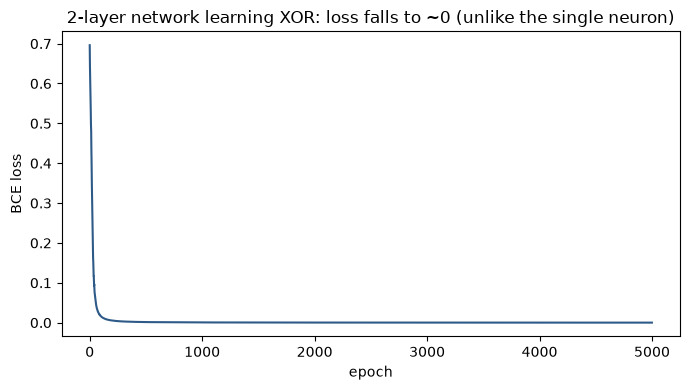

 x1  x2  prediction  target
  0   0      0.0002       0
  0   1      0.9999       1
  1   0      0.9999       1
  1   1      0.0001       0


In [2]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

net = NeuralNetwork(n_in=2, n_hidden=4, lr=1.0, seed=1)
losses = net.train(X_xor, y_xor, epochs=5000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color='#2E5A88')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('2-layer network learning XOR: loss falls to ~0 (unlike the single neuron)')
plt.tight_layout()
plt.show()

final_preds = net.predict(X_xor).ravel()
print(f"{'x1':>3} {'x2':>3} {'prediction':>11} {'target':>7}")
for x, pred, target in zip(X_xor, final_preds, y_xor):
    print(f"{x[0]:>3.0f} {x[1]:>3.0f} {pred:>11.4f} {target:>7.0f}")

## Aside — why `seed=1` and not just any seed

Worth being honest about: **not every random initialization converges.** Some
starting weights land every hidden neuron in a "dead ReLU" configuration (all
four give 0 for at least one input pattern, so their gradient is 0 there too)
or a symmetric arrangement the network can't easily break out of — and
training gets stuck at a much higher loss. This is exactly the failure mode
explored in depth in `notebooks/about-weights/symmetry_breaking_random_weights/`.

A quick scan across seeds makes the point concrete:

In [3]:
results = []
for seed in range(20):
    trial = NeuralNetwork(n_in=2, n_hidden=4, lr=1.0, seed=seed)
    trial_losses = trial.train(X_xor, y_xor, epochs=5000)
    results.append(trial_losses[-1])

results = np.array(results)
solved = results < 0.01
print(f"solved XOR (loss < 0.01): {solved.sum()}/20 seeds")
print("final losses:", np.round(results, 3))

solved XOR (loss < 0.01): 13/20 seeds
final losses: [0.    0.    0.    0.347 0.477 0.477 0.    0.477 0.477 0.    0.477 0.
 0.    0.    0.    0.    0.    0.347 0.    0.   ]


## Part 3 — Visualizing the decision boundary

A single neuron could only ever draw a straight line (Chapters 1 and 6). Color
every point in the plane by the network's prediction and see what a hidden
layer bought us: a **bent** boundary that a straight line could never produce.

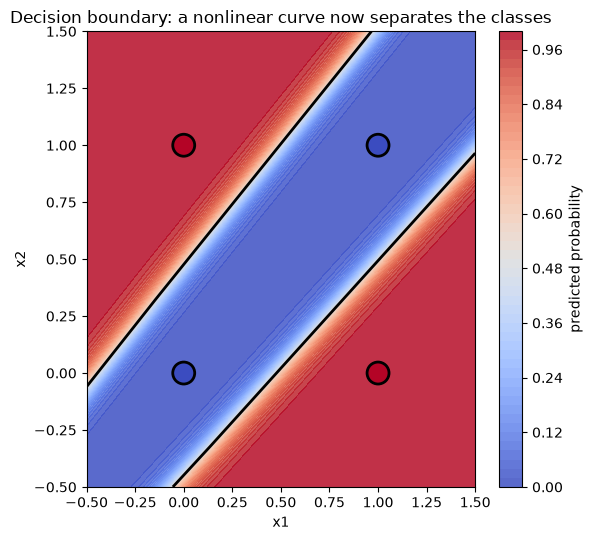

In [4]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_preds = net.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5.5))
contour = ax.contourf(xx, yy, grid_preds, levels=50, cmap='coolwarm', alpha=0.85)
ax.contour(xx, yy, grid_preds, levels=[0.5], colors='black', linewidths=2)
ax.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='coolwarm', s=250,
           edgecolors='black', linewidths=2, zorder=3)
plt.colorbar(contour, ax=ax, label='predicted probability')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Decision boundary: a nonlinear curve now separates the classes')
plt.tight_layout()
plt.show()

## Part 4 — Bonus: a less toy problem (two moons)

XOR has exactly 4 points — convincing, but small. Generate two interleaving
crescent-shaped clusters by hand (no libraries beyond numpy) and confirm the
same network, same code, generalizes to messier, noisier data.

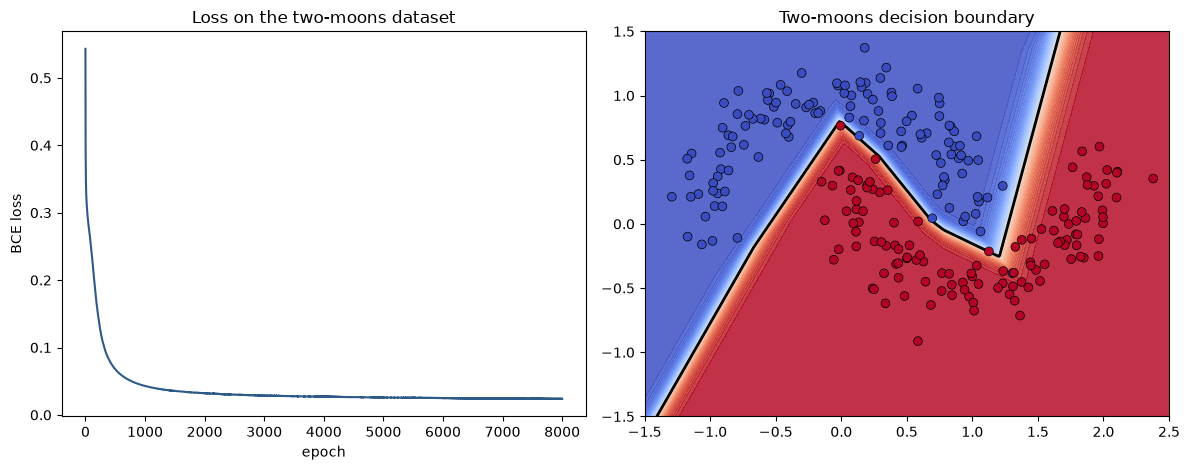

training accuracy: 99.2%


In [5]:
def make_moons_manual(n_samples=240, noise=0.15, seed=0):
    rng = np.random.default_rng(seed)
    n = n_samples // 2

    theta_a = np.linspace(0, np.pi, n)
    moon_a = np.column_stack([np.cos(theta_a), np.sin(theta_a)])

    theta_b = np.linspace(0, np.pi, n)
    moon_b = np.column_stack([1 - np.cos(theta_b), 1 - np.sin(theta_b) - 0.5])

    X = np.vstack([moon_a, moon_b])
    y = np.array([0] * n + [1] * n, dtype=float)
    X = X + rng.normal(scale=noise, size=X.shape)
    return X, y

X_moons, y_moons = make_moons_manual(seed=3)

moon_net = NeuralNetwork(n_in=2, n_hidden=8, lr=0.5, seed=3)
moon_losses = moon_net.train(X_moons, y_moons, epochs=8000)

xx2, yy2 = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1.5, 1.5, 300))
grid2 = np.column_stack([xx2.ravel(), yy2.ravel()])
grid_preds2 = moon_net.predict(grid2).reshape(xx2.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(moon_losses, color='#2E5A88')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Loss on the two-moons dataset')

axes[1].contourf(xx2, yy2, grid_preds2, levels=50, cmap='coolwarm', alpha=0.85)
axes[1].contour(xx2, yy2, grid_preds2, levels=[0.5], colors='black', linewidths=2)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', s=40,
                edgecolors='black', linewidths=0.5, zorder=3)
axes[1].set_title('Two-moons decision boundary')
plt.tight_layout()
plt.show()

accuracy = np.mean((moon_net.predict(X_moons).ravel() > 0.5) == y_moons)
print(f"training accuracy: {accuracy:.1%}")

## Recap: everything this series built, chained together

| Chapter | Building block | What it gave us |
|---|---|---|
| 1 | The neuron | `activation(weighted sum + bias)` |
| 2 | Activation functions | nonlinearity + a usable gradient |
| 3 | Layers & forward pass | neurons as one matrix multiply, chained |
| 4 | Loss functions | a single number to minimize |
| 5 | Backpropagation | the chain rule, computing every weight's gradient |
| 6 | Gradient descent | the update rule that improves the weights |
| 7 | Full network | all of the above, packaged and proven on XOR |

Every production framework (PyTorch, TensorFlow, JAX) automates exactly these
steps — automatic differentiation instead of Chapter 5's hand-derived
`backward()`, and optimizers like Adam instead of Chapter 6's plain gradient
descent — but the mechanism underneath is identical to what's in this folder.

**Where to go deeper in this repo:**
- `../Backpropagation_Deep_Dive.html` — a more thorough treatment of Chapter 5's topic
- `../Linear_to_Nonlinear_ReLU.html` — more on Chapter 2's nonlinearity question
- `../neuron_weight_explorer.html` / `../hidden_neurons_learn_pattern.html` — interactive versions of Chapters 1 and 3
- `notebooks/about-weights/symmetry_breaking_random_weights/` — why the *random* part of random weight initialization matters (glossed over here — we always seeded deterministically)
- `../Transformer_Backpropagation.html`, `../Tokenization_Embeddings_Attention.html` — where these building blocks lead next

**Next:** [Chapter 8 — Backpropagation Deep Dive](08_backpropagation_deep_dive.ipynb) digs into automatic differentiation and deeper networks; [Chapter 9 — Batch vs. Online Learning](09_batch_vs_online_learning.ipynb) explains the training-loop design choice made throughout this series.